<a href="https://colab.research.google.com/github/liam77773smith/cb2330-portfolio/blob/main/Kod_projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

When epsilon = 10 delta G = -2.6697948491924626 kcal/mol

DOPS pH 7
Observed delta G: -6.6 kcal/mol
Acceptance rate: 0.0
Estimated epsilon: 5.0 +/- 0.0 kcal/mol


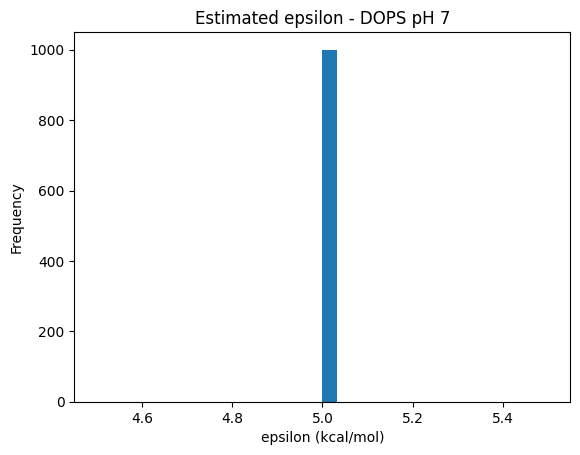

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# PARAMETERS

T = 323 # temperature 323K
k_B = 1.987 * (10**-3) # gas constant kcal/(mol*K)
z_max = 100 # max size of grid. z=0 is our membrane
steps = 100000 # number of steps in Monte Carlo
# epsilon = central fitted parameter.
# represents the specific energy penalty of leaving the membrane
# P = np.exp(-(epsilon / (k_B*T)))
# probability of accepting an energetically unfavorable move
# R = [0, 1] a random float between 0 and 1

# ASSUMPTIONS

# pH = 7 so that the output delta_G can be compared
# with the pH 7 values in Table 4

# z = 0 represents the membrane-bound state
# z > 0 represents the unbound state

# epsilon represents the effective energy difference
# between the bound and unbound state


# THE FORWARD LOOP

def forward_simulation(T, k_B, epsilon, steps, z_max):
    z_current = 50 # starting position
    z_pos = [] # empty list used later to store positions
    random_steps = np.random.choice([-1, 1], size=steps)
    for i in range(steps):
        dz = random_steps[i] # random step
        z_new = z_current + dz # new position
        # boundary checks
        if z_new < 0:
            z_new = 0 # reverts back to membrane
        elif z_new > z_max:
            z_new = z_current # revert back to current position
        # calculation of Energy change ("delta E")
        # Protein moves from unbound position z=1
        # to the membrane at z=0.
        # Energy is lowered by epsilon.
        if z_current == 1 and z_new == 0:
            delta_E = -epsilon
        # Protein moves away from the membrane
        # from z=0 to z=1.
        # This costs energy epsilon.
        elif z_current == 0 and z_new == 1:
            delta_E = +epsilon
        # Movement in the unbound region does not
        # change the energy in this simplified model.
        else: # z_current > 0 and z_new > 0
            delta_E = 0

        # THE METROPOLIS DECISION

        if delta_E <= 0: # move is neutral or lowers energy
            z_current = z_new # move accepted
        else: # move costs energy
            P = np.exp(-(delta_E / (k_B * T)))
            R = np.random.uniform(0, 1) # random number between 0 and 1
            if R < P:
                z_current = z_new
        z_pos.append(z_current)
    # ANALYSIS
    pos_arr = np.array(z_pos) # turn list into array
    n_bound = np.sum(pos_arr == 0) # calculate number of bound positions
    n_unbound = np.sum(pos_arr > 0) # calculate number of unbound positions
    if n_bound > 0 and n_unbound > 0:
        K = n_bound / n_unbound # calculate equilibrium ratio
        delta_G = (-k_B * T * np.log(K)) # calculate Gibbs free energy
    elif n_bound == 0:
        delta_G = 100 # kcal/mol
    else:

        # what happens if the protein never leaves the membrane
        # but it also means epsilon was estimated extremely strongly

        delta_G = -100 # kcal/mol
    return delta_G

# Forward simulation

epsilon = 10

delta_G = forward_simulation(T, k_B, epsilon, steps, z_max)

print("When epsilon =", epsilon, "delta G =", delta_G, "kcal/mol")

# Check finite delta G range

max_K = (steps - 1) / 1

min_finite_delta_G = -k_B * T * np.log(max_K)

DPPC_delta_G = -16.0
DOPS_delta_G = -6.6

if DPPC_delta_G < min_finite_delta_G:
    print("DPPC delta G cannot be reached with the current model")

if DOPS_delta_G < min_finite_delta_G:
    print("DOPS delta G cannot be reached with the current model.")

# Backward inference
PRIOR = (0.0, 30.0)
def abc_mcmc_energy(n_steps, tolerance, start, delta_G_obs, half_width=0.5):
    max_K = (steps - 1) / 1
    min_finite_delta_G = -k_B * T * np.log(max_K)
    if delta_G_obs < min_finite_delta_G:
        print(delta_G_obs, "cannot be reached")
        return None, 0
    epsilon = start
    chain = [0.0] * n_steps
    n_acc = 0
    for t in range(n_steps):
        # propose new epsilon close to current epsilon
        prop = epsilon + np.random.uniform(-half_width, half_width)
        if PRIOR[0] <= prop <= PRIOR[1]:
            delta_G_sim = forward_simulation(T, k_B,prop,steps,z_max)
            # accept if simulated delta G is close enough
            if abs(delta_G_sim - delta_G_obs) <= tolerance:
                epsilon = prop
                n_acc += 1
        chain[t] = epsilon
    return chain, n_acc
# DOPS pH 7
delta_G_obs = -6.6 # kcal/mol from Table 4
chain, n_acc = abc_mcmc_energy(n_steps=1000, tolerance=0.5,start=5.0, delta_G_obs=delta_G_obs,half_width=0.5)

if chain is not None:

    print("\nDOPS pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc / len(chain))
    print("Estimated epsilon:", np.mean(chain), "+/-", np.std(chain), "kcal/mol")

    plt.hist(chain, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DOPS pH 7")
    plt.show()


# DPPC pH 7

delta_G_obs = -16.0 # kcal/mol from Table 4

chain_DPPC, n_acc_DPPC = abc_mcmc_energy(n_steps=1000, tolerance=0.5, start=10.0, delta_G_obs=delta_G_obs,half_width=0.5)

if chain_DPPC is not None:

    print("\nDPPC pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc_DPPC / len(chain_DPPC))
    print("Estimated epsilon:", np.mean(chain_DPPC), "+/-", np.std(chain_DPPC), "kcal/mol")

    plt.hist(chain_DPPC, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DPPC pH 7")
    plt.show()

When epsilon = 10 delta G = -100 kcal/mol
DPPC delta G cannot be reached with the current model

DOPS pH 7
Observed delta G: -6.6 kcal/mol
Acceptance rate: 0.085
Estimated epsilon: 6.776836251467381 +/- 1.1493475538021178 kcal/mol


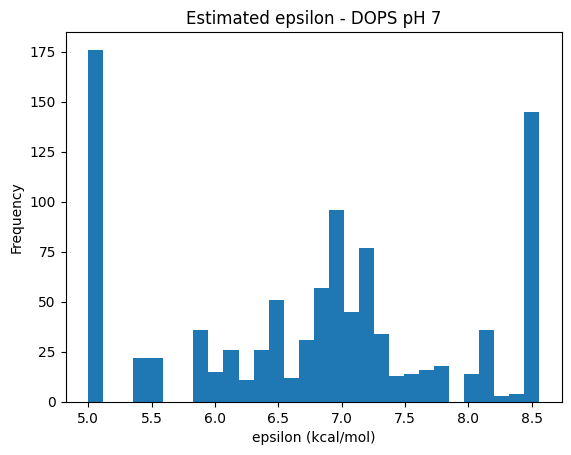

-16.0 cannot be reached


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS

T = 323 # temperature 323K
k_B = 1.987 * (10**-3) # Boltzmann constant kcal/(mol*K)
z_max = 100 # max size of grid. z=0 is our membrane
steps = 100000 # number of steps in Monte Carlo
equilibration_steps = 10000 # steps before positions are recorded

# epsilon = central fitted parameter.
# represents the specific energy penalty of leaving the membrane
# P = np.exp(-(epsilon / (k_B*T)))
# probability of accepting an energetically unfavorable move
# R = [0, 1] a random float between 0 and 1

# ASSUMPTIONS

# pH = 7 so that the output delta_G can be compared
# with the pH 7 values in Table 4

# z = 0 represents the membrane-bound state
# z > 0 represents the unbound state

# epsilon represents the effective energy difference
# between the bound and unbound state


# THE FORWARD LOOP

def forward_simulation(T, k_B, epsilon, steps, z_max):

    z_current = 50 # starting position
    z_pos = [] # empty list used later to store positions
    random_steps = np.random.choice([-1, 1], size=steps + equilibration_steps)
    for i in range(steps + equilibration_steps):
        dz = random_steps[i] # random step
        z_new = z_current + dz # new position
        # boundary checks
        if z_new < 0:
            z_new = 0 # reverts back to membrane
        elif z_new > z_max:
            z_new = z_current # revert back to current position
        # calculation of Energy change ("delta E")

        # Protein moves from unbound position z=1
        # to the membrane at z=0.
        # Energy is lowered by epsilon.

        if z_current == 1 and z_new == 0:
            delta_E = -epsilon

        # Protein moves away from the membrane
        # from z=0 to z=1.
        # This costs energy epsilon.

        elif z_current == 0 and z_new == 1:
            delta_E = +epsilon

        # Movement in the unbound region does not
        # change the energy in this simplified model.

        else: # z_current > 0 and z_new > 0
            delta_E = 0
        # THE METROPOLIS DECISION

        if delta_E <= 0: # move is neutral or lowers energy
            z_current = z_new # move accepted
        else: # move costs energy
            P = np.exp(-(delta_E / (k_B * T)))
            R = np.random.uniform(0, 1) # random number between 0 and 1
            if R < P:
                z_current = z_new
        # only record positions after equilibration
        if i >= equilibration_steps:
            z_pos.append(z_current)

    # ANALYSIS

    pos_arr = np.array(z_pos) # turn list into array
    n_bound = np.sum(pos_arr == 0) # calculate number of bound positions
    n_unbound = np.sum(pos_arr > 0) # calculate number of unbound positions
    if n_bound > 0 and n_unbound > 0:
        K = n_bound / n_unbound # calculate equilibrium ratio
        delta_G = (-k_B * T * np.log(K)) # calculate Gibbs free energy
    elif n_bound == 0:
        delta_G = 100 # kcal/mol
    else:
        # what happens if the protein never leaves the membrane
        # but it also means epsilon was estimated extremely strongly
        delta_G = -100 # kcal/mol
    return delta_G
# Forward simulation
epsilon = 10
delta_G = forward_simulation(T, k_B, epsilon, steps, z_max)
print("When epsilon =", epsilon, "delta G =", delta_G, "kcal/mol")
# Check finite delta G range
max_K = (steps - 1) / 1
min_finite_delta_G = -k_B * T * np.log(max_K)
DPPC_delta_G = -16.0
DOPS_delta_G = -6.6
if DPPC_delta_G < min_finite_delta_G:
    print("DPPC delta G cannot be reached with the current model")
if DOPS_delta_G < min_finite_delta_G:
    print("DOPS delta G cannot be reached with the current model.")
# Backward inference

PRIOR = (0.0, 30.0)

def abc_mcmc_energy(n_steps, tolerance, start, delta_G_obs, half_width=0.5):
    max_K = (steps - 1) / 1
    min_finite_delta_G = -k_B * T * np.log(max_K)
    if delta_G_obs < min_finite_delta_G:
        print(delta_G_obs, "cannot be reached")
        return None, 0
    epsilon = start
    chain = [0.0] * n_steps
    n_acc = 0
    for t in range(n_steps):
        # propose new epsilon close to current epsilon
        prop = epsilon + np.random.uniform(-half_width, half_width)
        if PRIOR[0] <= prop <= PRIOR[1]:
            delta_G_sim = forward_simulation(T, k_B, prop, steps, z_max)
            # accept if simulated delta G is close enough
            if abs(delta_G_sim - delta_G_obs) <= tolerance:
                epsilon = prop
                n_acc += 1
        chain[t] = epsilon
    return chain, n_acc
# DOPS pH 7

delta_G_obs = -6.6 # kcal/mol from Table 4
chain, n_acc = abc_mcmc_energy(n_steps=1000, tolerance=0.5, start=5.0, delta_G_obs=delta_G_obs, half_width=0.5)
if chain is not None:

    print("\nDOPS pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc / len(chain))
    print("Estimated epsilon:", np.mean(chain), "+/-", np.std(chain), "kcal/mol")

    plt.hist(chain, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DOPS pH 7")
    plt.show()

# DPPC pH 7

delta_G_obs = -16.0 # kcal/mol from Table 4
chain_DPPC, n_acc_DPPC = abc_mcmc_energy(n_steps=1000, tolerance=0.5, start=10.0, delta_G_obs=delta_G_obs, half_width=0.5)
if chain_DPPC is not None:

    print("\nDPPC pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc_DPPC / len(chain_DPPC))
    print("Estimated epsilon:", np.mean(chain_DPPC), "+/-", np.std(chain_DPPC), "kcal/mol")

    plt.hist(chain_DPPC, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DPPC pH 7")
    plt.show()

When epsilon = 10 delta G = -1.2844761018121476 kcal/mol

DOPS pH 7
Observed delta G: -6.6 kcal/mol
Acceptance rate: 0.736
Estimated epsilon: 9.555157167883404 +/- 0.2870933125535273 kcal/mol


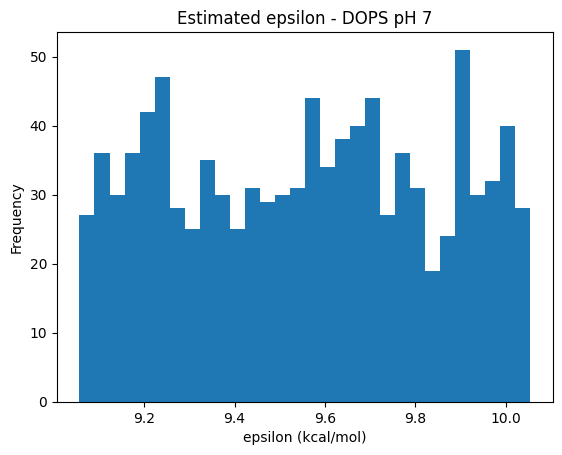


DPPC pH 7
Observed delta G: -16.0 kcal/mol
Acceptance rate: 0.738
Estimated epsilon: 18.969837872813354 +/- 0.28523799801801 kcal/mol


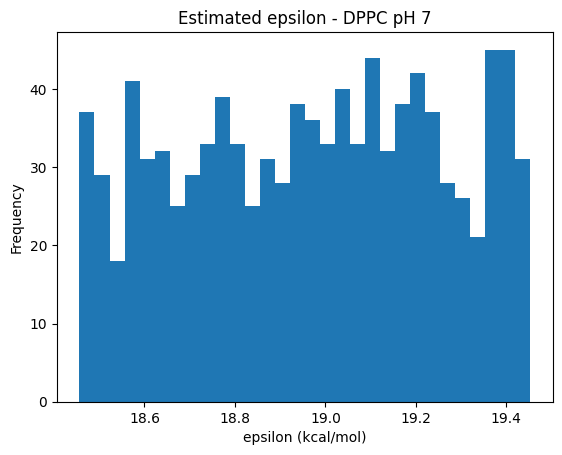

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS

T = 323 # temperature 323K
R = 1.987 * (10**-3) # gas constant kcal/(mol*K)
z_max = 100 # max size of grid. z=0 is our membrane
steps = 100000 # number of steps in Monte Carlo
equilibration_steps = 10000 # steps before positions are recorded

# epsilon = central fitted parameter.
# represents the specific energy penalty of leaving the membrane
# P = np.exp(-(epsilon / (R*T)))
# probability of accepting an energetically unfavorable move
# R = [0, 1] a random float between 0 and 1

# ASSUMPTIONS

# pH = 7 so that the output delta_G can be compared
# with the pH 7 values in Table 4

# z = 0 represents the membrane-bound state
# z > 0 represents the unbound state

# epsilon represents the effective energy difference
# between the bound and unbound state


# THE FORWARD LOOP

def forward_simulation(T, R, epsilon, steps, z_max):

    z_current = 50 # starting position
    z_pos = [] # empty list used later to store positions
    random_steps = np.random.choice([-1, 1], size=steps + equilibration_steps)
    for i in range(steps + equilibration_steps):
        dz = random_steps[i] # random step
        z_new = z_current + dz # new position
        # boundary checks
        if z_new < 0:
            z_new = 0 # reverts back to membrane
        elif z_new > z_max:
            z_new = z_current # revert back to current position
        # calculation of Energy change ("delta E")

        # Protein moves from unbound position z=1
        # to the membrane at z=0.
        # Energy is lowered by epsilon.

        if z_current == 1 and z_new == 0:
            delta_E = -epsilon

        # Protein moves away from the membrane
        # from z=0 to z=1.
        # This costs energy epsilon.

        elif z_current == 0 and z_new == 1:
            delta_E = +epsilon

        # Movement in the unbound region does not
        # change the energy in this simplified model.

        else: # z_current > 0 and z_new > 0
            delta_E = 0

        # THE METROPOLIS DECISION

        if delta_E <= 0: # move is neutral or lowers energy
            z_current = z_new # move accepted
        else: # move costs energy
            P = np.exp(-(delta_E / (R * T)))
            r = np.random.uniform(0, 1) # random number between 0 and 1
            if r < P:
                z_current = z_new

        # only record positions after equilibration

        if i >= equilibration_steps:
            z_pos.append(z_current)

    # ANALYSIS

    pos_arr = np.array(z_pos) # turn list into array
    n_bound = np.sum(pos_arr == 0) # calculate number of bound positions
    n_unbound = np.sum(pos_arr > 0) # calculate number of unbound positions

    if n_bound > 0 and n_unbound > 0:
        K = n_bound / n_unbound # calculate equilibrium ratio
        delta_G = (-R * T * np.log(K)) # calculate Gibbs free energy
    elif n_bound == 0:
        delta_G = 100 # kcal/mol
    else:
        # what happens if the protein never leaves the membrane
        # but it also means epsilon was estimated extremely strongly
        delta_G = -100 # kcal/mol

    return delta_G


# Forward simulation

epsilon = 10
delta_G = forward_simulation(T, R, epsilon, steps, z_max)
print("When epsilon =", epsilon, "delta G =", delta_G, "kcal/mol")


# equilibrium delta G for the same lattice model

def equilibrium_delta_G(T, R, epsilon, z_max):

    # one bound state and z_max unbound states

    K = np.exp(epsilon / (R * T)) / z_max
    delta_G = -R * T * np.log(K)

    return delta_G


# Backward inference

PRIOR = (0.0, 30.0)

def abc_mcmc_energy(n_steps, tolerance, start, delta_G_obs, half_width=0.5):

    epsilon = start
    chain = [0.0] * n_steps
    n_acc = 0

    for t in range(n_steps):

        # propose new epsilon close to current epsilon

        prop = epsilon + np.random.uniform(-half_width, half_width)

        if PRIOR[0] <= prop <= PRIOR[1]:

            delta_G_sim = equilibrium_delta_G(T, R, prop, z_max)

            # accept if simulated delta G is close enough

            if abs(delta_G_sim - delta_G_obs) <= tolerance:
                epsilon = prop
                n_acc += 1

        chain[t] = epsilon

    return chain, n_acc


# DOPS pH 7

delta_G_obs = -6.6 # kcal/mol from Table 4

chain, n_acc = abc_mcmc_energy(n_steps=1000, tolerance=0.5, start=9.0, delta_G_obs=delta_G_obs, half_width=0.5)

if chain is not None:

    print("\nDOPS pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc / len(chain))
    print("Estimated epsilon:", np.mean(chain), "+/-", np.std(chain), "kcal/mol")

    plt.hist(chain, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DOPS pH 7")
    plt.show()


# DPPC pH 7

delta_G_obs = -16.0 # kcal/mol from Table 4

chain_DPPC, n_acc_DPPC = abc_mcmc_energy(n_steps=1000, tolerance=0.5, start=19.0, delta_G_obs=delta_G_obs, half_width=0.5)

if chain_DPPC is not None:

    print("\nDPPC pH 7")
    print("Observed delta G:", delta_G_obs, "kcal/mol")
    print("Acceptance rate:", n_acc_DPPC / len(chain_DPPC))
    print("Estimated epsilon:", np.mean(chain_DPPC), "+/-", np.std(chain_DPPC), "kcal/mol")

    plt.hist(chain_DPPC, bins=30)
    plt.xlabel("epsilon (kcal/mol)")
    plt.ylabel("Frequency")
    plt.title("Estimated epsilon - DPPC pH 7")
    plt.show()